# Conversión de firmas espectrales de PRISMA

In [11]:

#!pip install git+https://github.com/fnemina/SpecDAL

import numpy as np
import pandas as pd
import specdal
import os
import matplotlib.pyplot as plt

In [2]:
import rasterio
# Copio las descripciones en el nombre de banda del tif original al tif georreferenciado
original = rasterio.open('..\datos\imagen_202204\PRS_L2D_STD_20220402140222_20220402140226_0001.tif')
modificado = rasterio.open('..\datos\imagen_202204\PRS_L2D_STD_20220402140222_20220402140226_0001_modificado.tif', 'r+')
modificado.descriptions = original.descriptions
modificado.close()
original.close()

## Función de conversión

In [3]:
def read_prisma_reflectance(filename, name="", measure_type="tgt_reflect", metadata={},
                            scale=1.5259021896696422e-05):
    """ Esta función convierte un archivo con una firma espectral de PRISMA a el objeto
        Spectrum() de specdal"""
    
    # Creamos dos arrays para guardar la reflectancia y la longitud de onda
    wl = []
    rho = []
    
    # Abrimos el archivo linea por linea
    with open(filename) as file:
        for s in file:
            # Acomodamos el final del string
            s = s.strip()
            # Elegimos el 4 y el 6 valor al separar por espacios
            #     Banda 001: Band 1 (406.99341 Nanometers): 4894
            #     0     1    2    3 4          5            6
            # y lo convertimos a float después de acomodarlo
            wl.append(float(s.split(" ")[4].replace("(","")))
            rho.append(float(s.split(" ")[6]))
           
    # Convertimos los arrays a numpy
    wl = np.array(wl)
    rho = np.array(rho)
    
    # Creamos el objeto spectrum
    metadata["scale"] = scale
    measurement = pd.Series(data=rho*scale, index=wl, name="wavelength")
    measurement.index.name = "wavelength"
    spectrum = specdal.Spectrum(measurement=measurement, name=name, 
                                measure_type=measure_type, metadata=metadata)
    return spectrum

## Ejemplo: lectura de un archivo

In [5]:
filename = "../datos/imagen_202204/firmas/firma1.txt"
spectrum = read_prisma_reflectance(filename, name="PRISMA")
print(spectrum)


name:		PRISMA,
measure_type:	tgt_reflect
measurements:	wave  |measurement
		------|-----------
		 407.0|0.075
		   ...|...
		2497.1|0.001
metadata:	scale:1.5259021896696422e-05



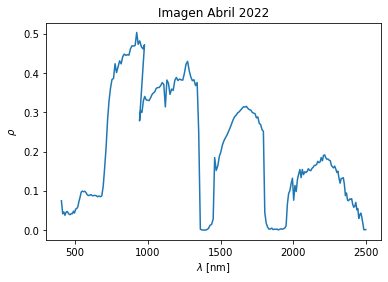

In [14]:
spectrum.plot()
plt.xlabel(r"$\lambda$ [nm]")
plt.ylabel(r"$\rho$")
plt.title("Imagen Abril 2022")
plt.show()

## Ejemplo: lectura de varios archivos

In [8]:
# Lectura de varios archivos
folder = "../datos/imagen_202204/firmas/"
collection = specdal.Collection(name="PRISMA", measure_type="tgt_reflectance")
for filename in os.listdir(folder):
    spectra = read_prisma_reflectance(folder+filename, name=filename.replace(".txt",""))
    collection.append(spectra)

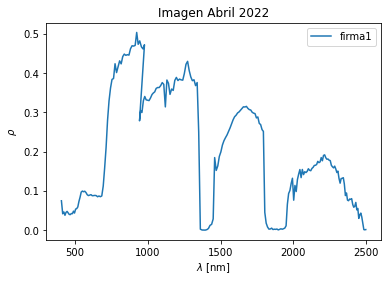

In [13]:
collection.plot()
plt.xlabel(r"$\lambda$ [nm]")
plt.ylabel(r"$\rho$")
plt.title("Imagen Abril 2022")
plt.show()